# Credit Card Fraud Detection using Machine Learning

## Objective
Develop a machine learning model to classify credit card transactions as fraudulent or legitimate. Since fraud cases are extremely rare compared to normal transactions, the project focuses on handling class imbalance and evaluating models using appropriate metrics.

## Dataset
The dataset contains anonymized credit card transactions, where the target variable `Class` indicates:
- 0: Legitimate transaction
- 1: Fraudulent transaction

The dataset includes features such as transaction time, transaction amount, and anonymized variables (V1–V28).

## Workflow
1. Import libraries
2. Load the dataset
3. Perform exploratory data analysis (EDA)
4. Engineer new features
5. Preprocess the data
6. Train Random Forest and XGBoost models
7. Evaluate and compare model performance
8. Save the best-performing model

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# XGBoost
from xgboost import XGBClassifier

# Load Dataset

The Credit Card Fraud Detection dataset is loaded into a Pandas DataFrame for analysis and model development.

In [33]:
# Loading DataSet
df=pd.read_csv('creditcard.csv')

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the dataset, identify missing values, examine the distribution of the target variable, and gain insights into the transaction features before training the machine learning models.

In [34]:
# Display the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [36]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [37]:
# Summary statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [38]:
# Check for missing values
df.isnull().sum()

# Hence, No null values to be handled

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [39]:
# Class distribution
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


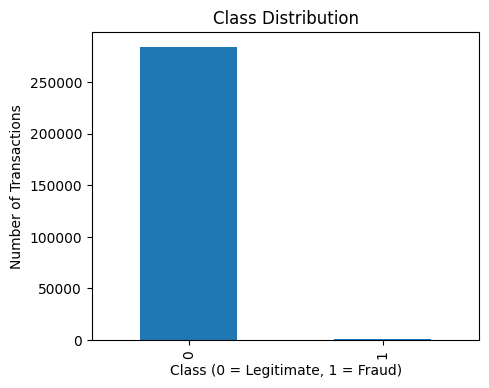

In [40]:
# Class distribution plot
plt.figure(figsize=(5,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

# This proves that we will have to increase weight of fraud cases in required scenarios

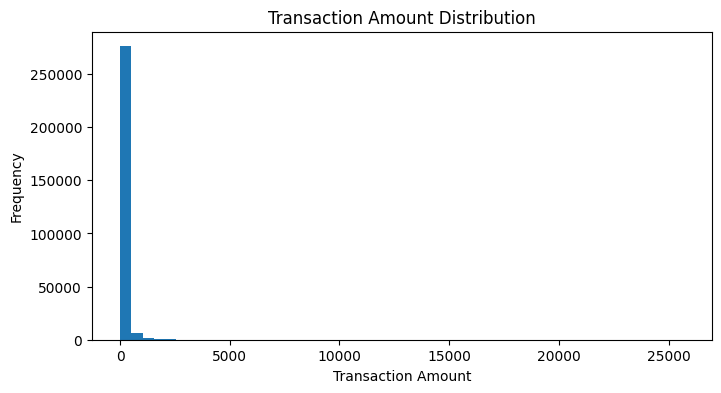

In [41]:
# Transaction amount distribution
plt.figure(figsize=(8,4))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

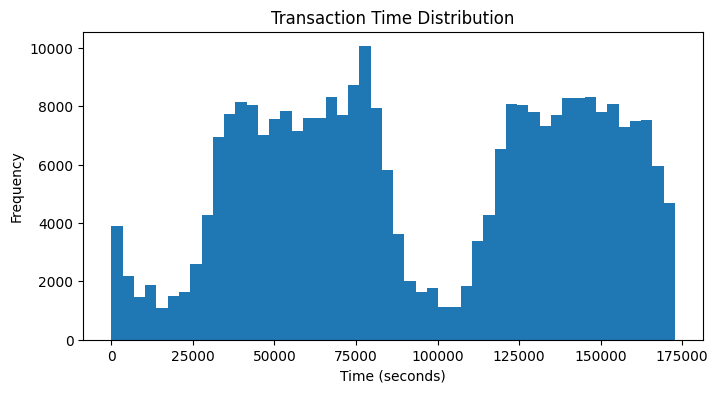

In [42]:
# Transaction time distribution
plt.figure(figsize=(8,4))
plt.hist(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()

# Feature Engineering

Additional features are created from the existing data to improve model performance. Time-based features are extracted from the transaction timestamp, while a logarithmic transformation is applied to the transaction amount to reduce skewness.

In [43]:
### Feature Engineering

# Extract the hour of the transaction (0–23)
df["Hour"] = (df["Time"] // 3600) % 24

# Encode the hour as cyclical features
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

# Apply log transformation to reduce skewness in transaction amounts
df["LogAmount"] = np.log1p(df["Amount"])

# Display the newly created features
df[["Time", "Hour", "Hour_sin", "Hour_cos", "Amount", "LogAmount"]].head()

,Time,Hour,Hour_sin,Hour_cos,Amount,LogAmount
0,0.0,0.0,0.0,1.0,149.62,5.014760
1,0.0,0.0,0.0,1.0,2.69,1.305626
2,1.0,0.0,0.0,1.0,378.66,5.939276
3,1.0,0.0,0.0,1.0,123.50,4.824306
4,2.0,0.0,0.0,1.0,69.99,4.262539


# Data Preprocessing

The dataset is prepared for machine learning by separating the input features and target variable, splitting the data into training and testing sets, and standardizing the numerical features using StandardScaler.

In [44]:
### Data Preprocessing

# Separate features and target variable
X = df.drop("Class", axis=1)
y = df["Class"]

#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
# Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random Forest Model

A Random Forest classifier is trained to classify transactions as legitimate or fraudulent. Class weights are used to reduce the impact of class imbalance and improve fraud detection performance.

In [46]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight={0: 1, 1: 10},
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
# Predict class labels and probabilities
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Random Forest Evaluation

The performance of the Random Forest model is evaluated using the Confusion Matrix, Classification Report, ROC Curve, and ROC AUC score.

In [48]:
# Evaluating Model
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix
[[56860     4]
 [   21    77]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC AUC Score: 0.9630612567902795


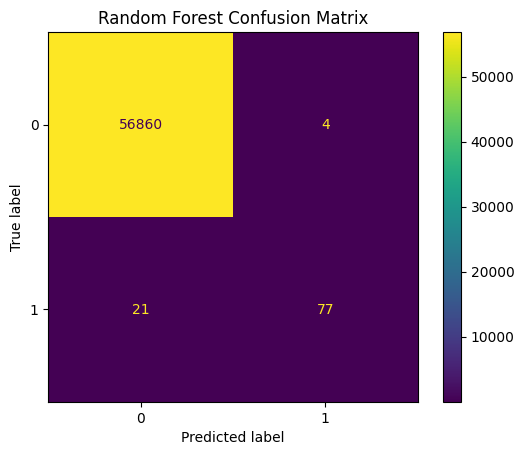

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")
plt.show()

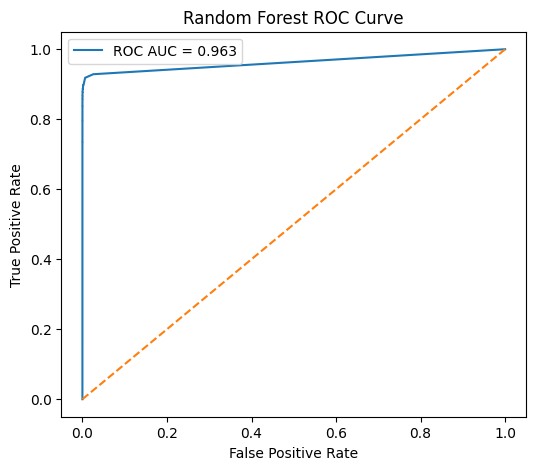

In [50]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()

# XGBoost Model

An XGBoost classifier is trained using the same preprocessed dataset. The `scale_pos_weight` parameter is used to assign greater importance to fraudulent transactions during training.

In [51]:
# Initialize the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=100,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [52]:
# Predict probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Convert probabilities to class labels
y_pred_xgb = (y_prob_xgb > 0.7).astype(int)

# XGBoost Evaluation

The XGBoost model is evaluated using the Confusion Matrix, Classification Report, ROC Curve, and ROC AUC score to compare its performance with the Random Forest model.

In [53]:
#Evaluating Mode
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nROC AUC Score:", roc_auc_score(y_test, y_prob_xgb))

Confusion Matrix
[[56814    50]
 [   13    85]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.87      0.73        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962


ROC AUC Score: 0.980411461503566


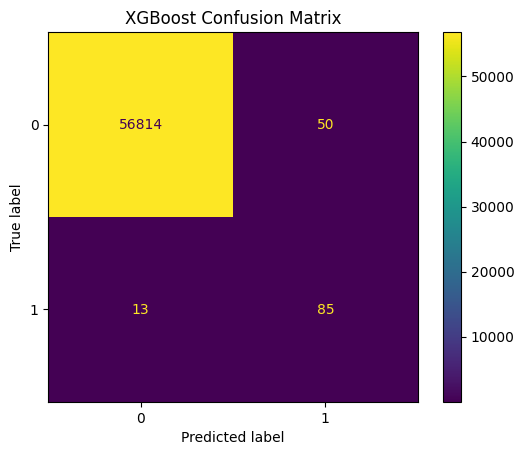

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("XGBoost Confusion Matrix")
plt.show()

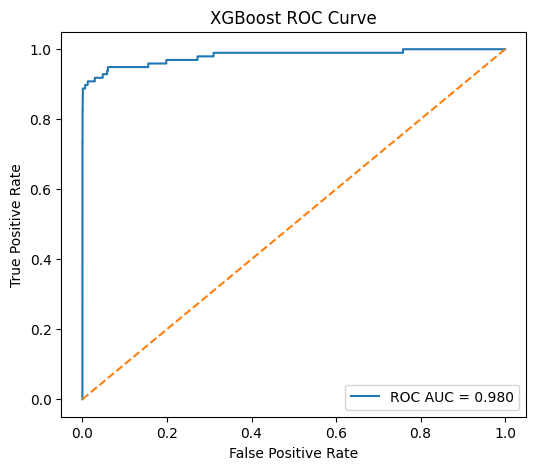

In [55]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob_xgb):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()

plt.show()

# Model Comparison

The performance of both machine learning models is compared using Precision, Recall, F1-score, and ROC AUC. This comparison highlights the trade-offs between fraud detection capability and false positive rates.

In [56]:
comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC AUC"
    ],
    "Random Forest": [
        0.95,
        0.79,
        0.86,
        0.963
    ],
    "XGBoost": [
        0.63,
        0.87,
        0.73,
        0.980
    ]
})

comparison

,Metric,Random Forest,XGBoost
0,Precision,0.950,0.63
1,Recall,0.790,0.87
2,F1-Score,0.860,0.73
3,ROC AUC,0.963,0.98


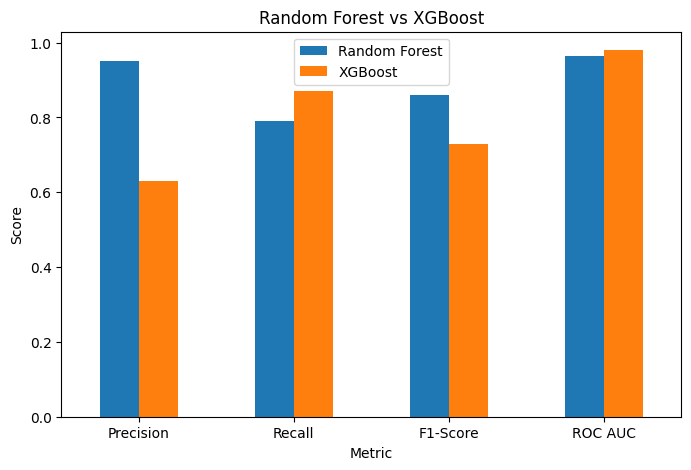

In [57]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Random Forest vs XGBoost")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# Conclusion

This project developed a machine learning pipeline to detect fraudulent credit card transactions using the Credit Card Fraud Detection dataset. The workflow included data exploration, feature engineering, preprocessing, model training, and performance evaluation.

Both Random Forest and XGBoost were evaluated using Precision, Recall, F1-score, and ROC AUC. Random Forest provided the best overall balance between precision and recall, while XGBoost achieved a higher ROC AUC and recall at the cost of more false positives.

This project demonstrates the importance of selecting appropriate evaluation metrics for imbalanced datasets and highlights the trade-offs between different machine learning models.